# Exploratory Data Analysis (EDA) on Marketing Campaign Dataset

## Objective
The objective of this project is to analyze a marketing campaign dataset, understand campaign performance, visualize the marketing funnel, calculate Return on Investment (ROI), and recommend which marketing channels should receive more budget based on business insights.

# 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# 2. Load Dataset

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Divya\Downloads\digital_marketing_dataset_30k.csv")

df.head()

,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),...,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
0,08/04/2023,2023,4,Apr,14,Sat,7,Spring,0,No,...,AD8747890,In-Feed_V1,871.17,172632,77865,2.22,1440,0,0.00,54610
1,28/04/2025,2025,4,Apr,18,Mon,12,Spring,0,No,...,AD2884130,Feed_V9,362.55,30111,15083,2.00,283,0,0.00,8086
2,18/12/2024,2024,12,Dec,51,Wed,10,Winter,0,No,...,AD5656772,Display_V7,362.09,111125,56453,1.97,1238,7,671.74,0
3,26/04/2024,2024,4,Apr,17,Fri,20,Spring,0,No,...,AD3443678,Stories_V2,54.45,10844,4736,2.29,83,0,0.00,0
4,19/04/2024,2024,4,Apr,16,Fri,22,Spring,0,No,...,AD8461978,Reels_V8,56.18,6423,3010,2.13,59,0,0.00,1160


# 3. Data Understanding

In [4]:
# Shape of the dataset
print("Shape of the dataset:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# First few rows
print("\nFirst 5 Rows:")
display(df.head())

Shape of the dataset: (30000, 35)

Column Names:
['date', 'year', 'month', 'month_name', 'week', 'day_of_week', 'post_hour', 'season', 'is_holiday', 'is_holiday (text)', 'is_weekend', 'is_weekend (text)', 'country', 'market_tier', 'account', 'account_type', 'platform', 'placement', 'funnel_stage', 'objective', 'theme', 'campaign_id', 'campaign_name', 'ad_group_id', 'ad_group_name', 'ad_id', 'ad_name', 'spend', 'impressions', 'reach', 'frequency', 'clicks', 'conversions', 'revenue', 'video_views']

Data Types:
date                  object
year                   int64
month                  int64
month_name            object
week                   int64
day_of_week           object
post_hour              int64
season                object
is_holiday             int64
is_holiday (text)     object
is_weekend             int64
is_weekend (text)     object
country               object
market_tier           object
account               object
account_type          object
platform             

,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),...,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
0,08/04/2023,2023,4,Apr,14,Sat,7,Spring,0,No,...,AD8747890,In-Feed_V1,871.17,172632,77865,2.22,1440,0,0.00,54610
1,28/04/2025,2025,4,Apr,18,Mon,12,Spring,0,No,...,AD2884130,Feed_V9,362.55,30111,15083,2.00,283,0,0.00,8086
2,18/12/2024,2024,12,Dec,51,Wed,10,Winter,0,No,...,AD5656772,Display_V7,362.09,111125,56453,1.97,1238,7,671.74,0
3,26/04/2024,2024,4,Apr,17,Fri,20,Spring,0,No,...,AD3443678,Stories_V2,54.45,10844,4736,2.29,83,0,0.00,0
4,19/04/2024,2024,4,Apr,16,Fri,22,Spring,0,No,...,AD8461978,Reels_V8,56.18,6423,3010,2.13,59,0,0.00,1160


# 4. Data Cleaning

In [5]:
# Missing values
print("Missing Values:")
display(df.isnull().sum())

# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Missing Values:


date                 0
year                 0
month                0
month_name           0
week                 0
day_of_week          0
post_hour            0
season               0
is_holiday           0
is_holiday (text)    0
is_weekend           0
is_weekend (text)    0
country              0
market_tier          0
account              0
account_type         0
platform             0
placement            0
funnel_stage         0
objective            0
theme                0
campaign_id          0
campaign_name        0
ad_group_id          0
ad_group_name        0
ad_id                0
ad_name              0
spend                0
impressions          0
reach                0
frequency            0
clicks               0
conversions          0
revenue              0
video_views          0
dtype: int64

Duplicate Rows: 0


In [6]:
df.describe(include='all')

,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),...,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
count,30000,30000.000000,30000.000000,30000,30000.0000,30000,30000.000000,30000,30000.000000,30000,...,30000,30000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
unique,1096,NaN,NaN,12,NaN,7,NaN,4,NaN,2,...,29956,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,27/04/2025,NaN,NaN,Jul,NaN,Mon,NaN,Spring,NaN,No,...,AD2367372,Feed_V2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,45,NaN,NaN,2618,NaN,4363,NaN,7644,NaN,29525,...,2,865,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2023.995833,6.528000,NaN,26.4568,NaN,11.504133,NaN,0.015833,NaN,...,NaN,NaN,421.213635,5.672545e+04,28648.652500,2.068052,853.904667,10.759933,475.711809,5176.542333
std,NaN,0.815540,3.451774,NaN,15.0875,NaN,6.916279,NaN,0.124833,NaN,...,NaN,NaN,463.299038,8.022802e+04,41973.091136,0.415826,1485.987745,54.295895,2814.167209,13486.544115
min,NaN,2023.000000,1.000000,NaN,1.0000,NaN,0.000000,NaN,0.000000,NaN,...,NaN,NaN,18.840000,6.930000e+02,277.000000,1.110000,3.000000,0.000000,0.000000,0.000000
25%,NaN,2023.000000,4.000000,NaN,13.0000,NaN,5.000000,NaN,0.000000,NaN,...,NaN,NaN,86.147500,9.432750e+03,4652.750000,1.750000,109.000000,0.000000,0.000000,0.000000
50%,NaN,2024.000000,7.000000,NaN,27.0000,NaN,11.000000,NaN,0.000000,NaN,...,NaN,NaN,229.915000,2.543800e+04,12516.000000,2.060000,311.500000,1.000000,0.000000,0.000000
75%,NaN,2025.000000,10.000000,NaN,40.0000,NaN,18.000000,NaN,0.000000,NaN,...,NaN,NaN,609.312500,6.961450e+04,34562.250000,2.370000,961.000000,3.000000,72.350000,3245.250000


In [7]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

In [8]:
df['date'].dtype

dtype('<M8[ns]')

# 5. Exploratory Data Analysis (EDA)

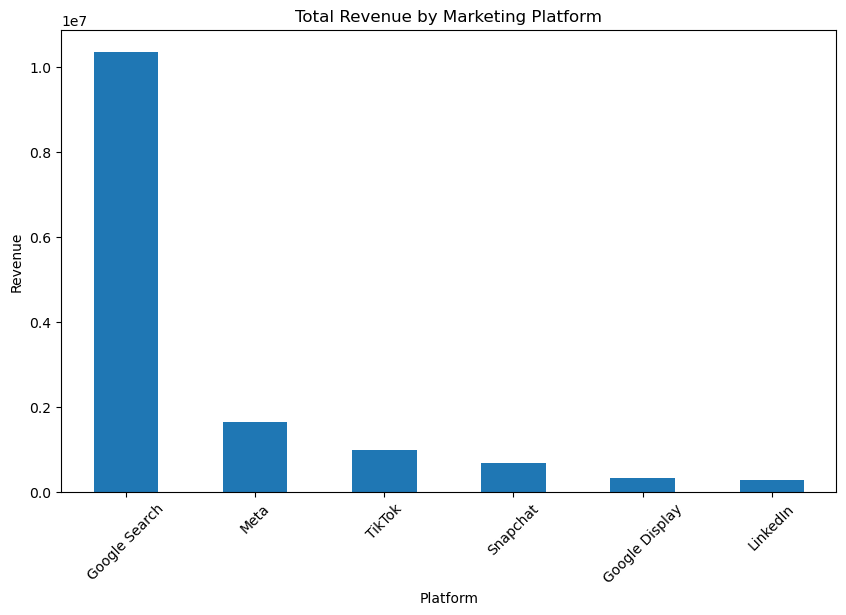

In [9]:
platform_revenue = (
    df.groupby('platform')['revenue']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

platform_revenue.plot(kind='bar')

plt.title("Total Revenue by Marketing Platform")
plt.xlabel("Platform")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

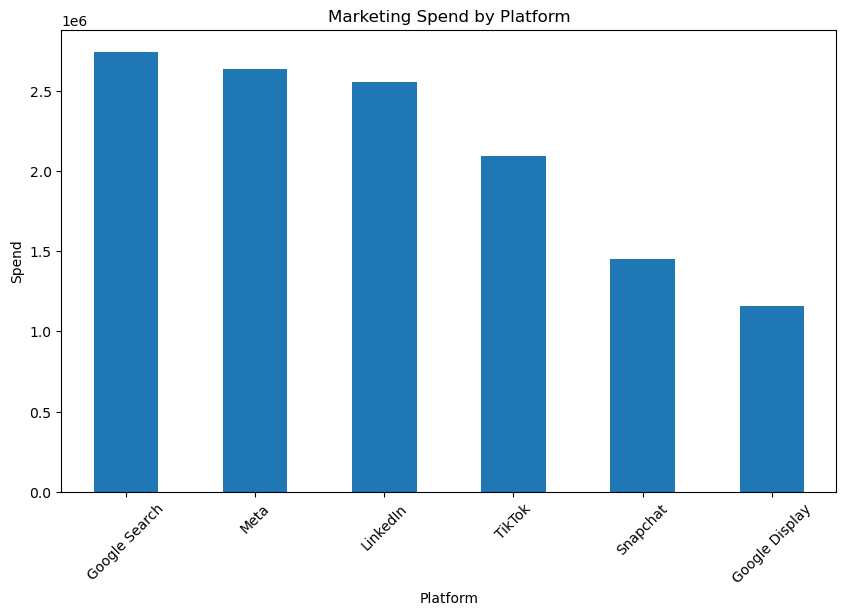

In [10]:
platform_spend = (
    df.groupby('platform')['spend']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

platform_spend.plot(kind='bar')

plt.title("Marketing Spend by Platform")
plt.xlabel("Platform")
plt.ylabel("Spend")

plt.xticks(rotation=45)

plt.show()

ROI Calculation 

In [11]:
df['ROI'] = ((df['revenue'] - df['spend']) / df['spend']) * 100

In [12]:
df[['spend','revenue','ROI']].head()

,spend,revenue,ROI
0,871.17,0.00,-100.000000
1,362.55,0.00,-100.000000
2,362.09,671.74,85.517413
3,54.45,0.00,-100.000000
4,56.18,0.00,-100.000000


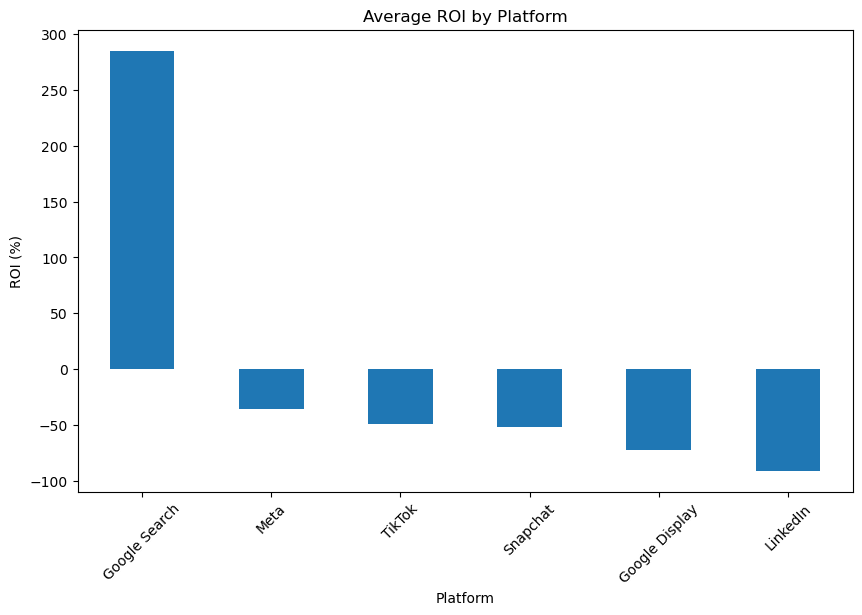

In [13]:
roi_platform = (
    df.groupby('platform')['ROI']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

roi_platform.plot(kind='bar')

plt.title("Average ROI by Platform")
plt.xlabel("Platform")
plt.ylabel("ROI (%)")

plt.xticks(rotation=45)

plt.show()

In [14]:
df['CTR'] = (df['clicks'] / df['impressions']) * 100

In [15]:
df['Conversion_Rate'] = (df['conversions'] / df['clicks']) * 100

In [16]:
df[['CTR','Conversion_Rate','ROI']].describe()

,CTR,Conversion_Rate,ROI
count,30000.000000,30000.000000,30000.000000
mean,1.823630,0.831481,7.615892
std,2.022371,1.548742,388.210918
min,0.186053,0.000000,-100.000000
25%,0.728176,0.000000,-100.000000
50%,0.985030,0.047782,-100.000000
75%,1.436671,1.162791,-51.085793
max,13.759800,13.907658,9100.115325


# 6. Marketing Funnel Analysis

In [17]:
funnel = pd.DataFrame({
    'Stage': ['Impressions', 'Clicks', 'Conversions'],
    'Total': [
        df['impressions'].sum(),
        df['clicks'].sum(),
        df['conversions'].sum()
    ]
})

funnel

,Stage,Total
0,Impressions,1701763447
1,Clicks,25617140
2,Conversions,322798


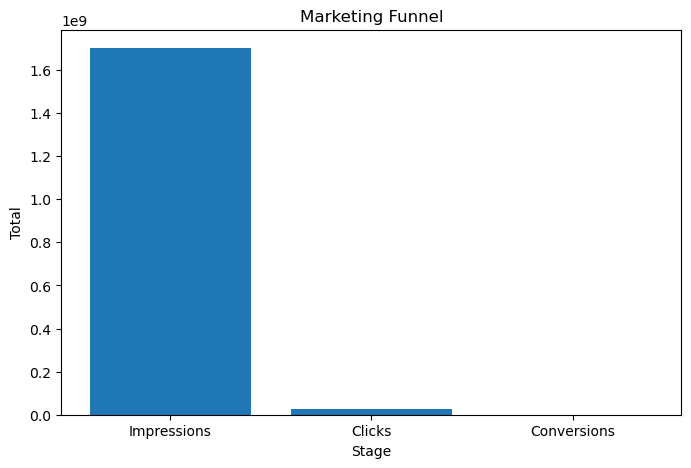

In [18]:
plt.figure(figsize=(8,5))

plt.bar(funnel['Stage'], funnel['Total'])

plt.title("Marketing Funnel")

plt.xlabel("Stage")

plt.ylabel("Total")

plt.show()

# 7. Advanced Data Analysis

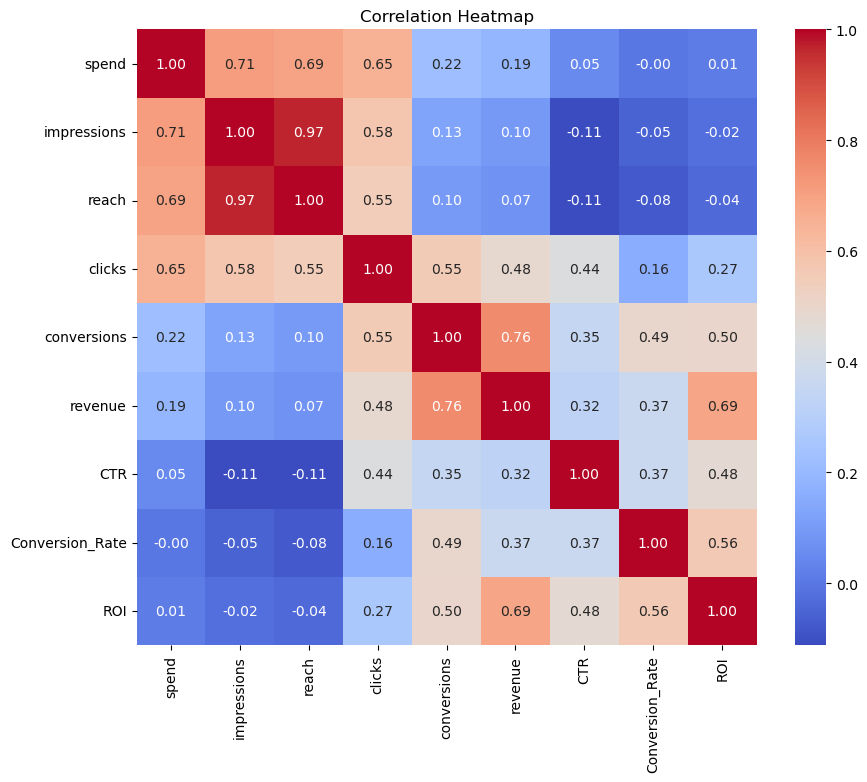

In [19]:
plt.figure(figsize=(10,8))

numeric_cols = ['spend', 'impressions', 'reach', 'clicks',
                'conversions', 'revenue', 'CTR',
                'Conversion_Rate', 'ROI']

sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

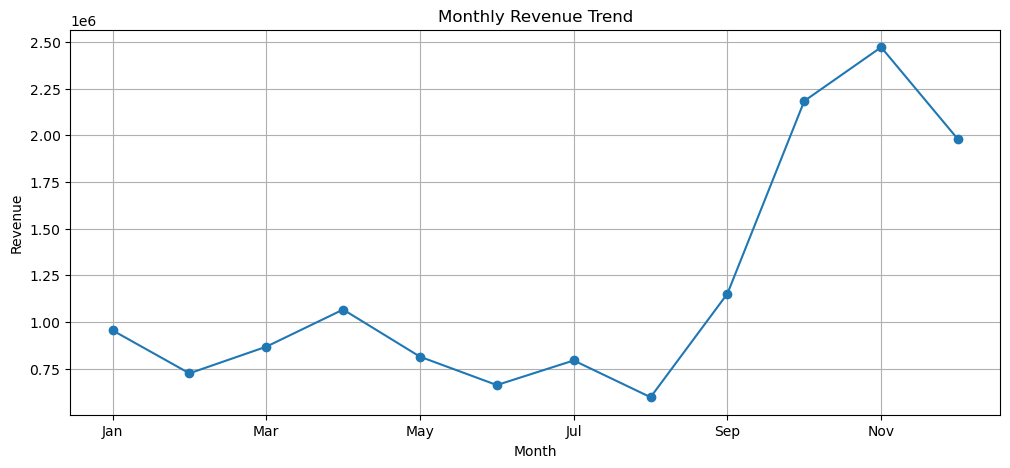

In [20]:
monthly_revenue = (
    df.groupby('month_name')['revenue']
      .sum()
      .reindex(['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec'])
)

plt.figure(figsize=(12,5))

monthly_revenue.plot(marker='o')

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

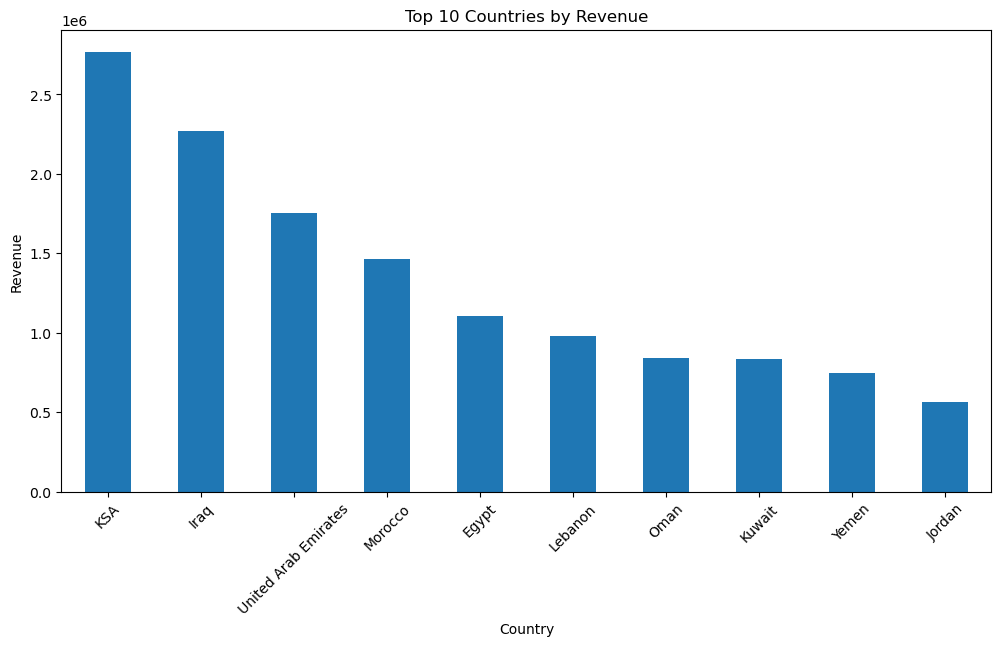

In [21]:
country_revenue = (
    df.groupby('country')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

country_revenue.plot(kind='bar')

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Country")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

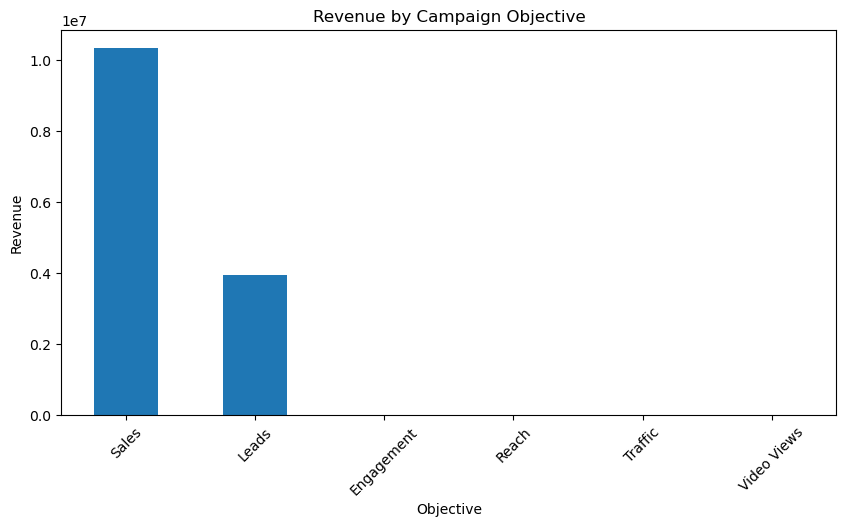

In [22]:
objective_revenue = (
    df.groupby('objective')['revenue']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

objective_revenue.plot(kind='bar')

plt.title("Revenue by Campaign Objective")

plt.xlabel("Objective")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

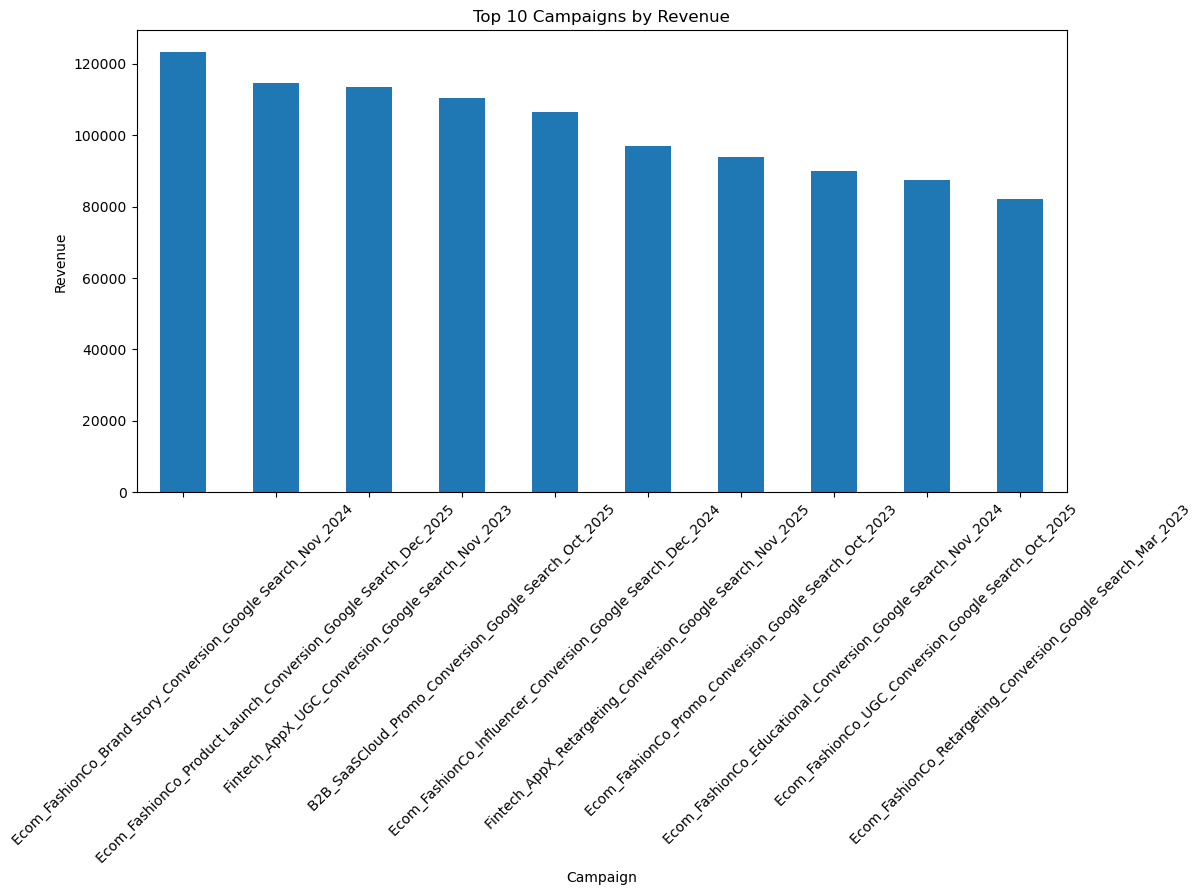

In [23]:
top_campaigns = (
    df.groupby('campaign_name')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_campaigns.plot(kind='bar')

plt.title("Top 10 Campaigns by Revenue")

plt.xlabel("Campaign")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [24]:
platform_summary = (
    df.groupby('platform')
      .agg({
          'spend':'sum',
          'revenue':'sum',
          'clicks':'sum',
          'conversions':'sum',
          'ROI':'mean'
      })
      .round(2)
)

platform_summary

,spend,revenue,clicks,conversions,ROI
platform,,,,,
Google Display,1157077.08,328505.21,1809793,9109,-71.85
Google Search,2744251.20,10362175.17,11515557,216694,284.97
LinkedIn,2556360.66,276970.44,685644,5588,-90.82
Meta,2636602.54,1640105.78,4439765,41978,-35.16
Snapchat,1450865.95,669736.81,3230264,21148,-51.52
TikTok,2091251.63,993860.85,3936117,28281,-49.36


# 8. Business Insights

## Business Insights

- Google Search generated the highest revenue among all marketing platforms.

- Google Search achieved the highest Return on Investment (ROI), making it the most profitable marketing channel.

- Meta and TikTok generated moderate revenue but delivered comparatively lower ROI.

- LinkedIn and Google Display recorded the lowest ROI despite advertising expenditure.

- The marketing funnel shows a substantial reduction from impressions to clicks and finally conversions.

- Revenue varied across different months, indicating seasonal trends.

- Campaign objectives significantly influenced campaign performance.

# 9. Final Recommendation

## Budget Allocation Recommendation

Based on the ROI analysis, Google Search should receive the highest marketing budget because it consistently generated the highest revenue and ROI.

Meta and TikTok campaigns should continue with optimized targeting and audience segmentation.

Budget allocation for LinkedIn and Google Display should be reduced until campaign performance improves.

Future marketing investments should prioritize high-ROI platforms while continuously monitoring campaign effectiveness.